# Challenge Data — Maladie de Parkinson
## Prédire et Corriger les Biais dans l'Évaluation du Score Moteur

**Stratégie** : Le cœur du problème est pharmacocinétique. Le score ON observé est le score OFF "vrai" auquel s'ajoute l'effet du médicament. Plus le délai depuis la dernière prise est court, plus le médicament est efficace et plus le score ON est bas (bon état moteur). On va exploiter cette physique pour créer un proxy du score OFF, puis ajouter des features temporelles par patient.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import Ridge
import xgboost as xgb

# LightGBM — installer si besoin : pip install lightgbm
try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    print("LightGBM non disponible, on utilisera uniquement XGBoost")
    HAS_LGB = False

SEED = 42
np.random.seed(SEED)

LightGBM non disponible, on utilisera uniquement XGBoost


## 0. Chargement des données

In [6]:
X_train_raw = pd.read_csv("données/X_train_6ZIKlTY.csv")
y_train     = pd.read_csv("données/y_train_lXj6X5y.csv")
X_test_raw  = pd.read_csv("données/X_test_oiZ2ukx.csv")

print("Train:", X_train_raw.shape, "| Test:", X_test_raw.shape)
X_train_raw.head(3)

Train: (55603, 12) | Test: (23672, 13)


,Index,patient_id,cohort,sexM,gene,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off
0,0,IPLP5212,A,0,LRRK2+,48.5,52.1,607.0,1.9,NaN,7.0,NaN
1,1,IPLP5212,A,0,LRRK2+,48.5,53.0,666.0,1.9,17.6,12.0,44.0
2,2,IPLP5212,A,0,LRRK2+,48.5,53.9,717.0,1.2,NaN,6.0,NaN


In [7]:
X_train_raw["time_since_diagnosis"] = X_train_raw["age"] - X_train_raw["age_at_diagnosis"]

X_train_raw.head(3)

,Index,patient_id,cohort,sexM,gene,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off,time_since_diagnosis
0,0,IPLP5212,A,0,LRRK2+,48.5,52.1,607.0,1.9,NaN,7.0,NaN,3.6
1,1,IPLP5212,A,0,LRRK2+,48.5,53.0,666.0,1.9,17.6,12.0,44.0,4.5
2,2,IPLP5212,A,0,LRRK2+,48.5,53.9,717.0,1.2,NaN,6.0,NaN,5.4


## 1. Exploration rapide

In [3]:
# Valeurs manquantes
print("=== Train — % NaN ===")
print((X_train_raw.isnull().mean() * 100).round(1).sort_values(ascending=False))
print("\n=== Test — % NaN ===")
print((X_test_raw.isnull().mean() * 100).round(1).sort_values(ascending=False))

=== Train — % NaN ===
time_since_intake_off    78.8
time_since_intake_on     46.7
off                      42.1
ledd                     37.0
gene                     32.3
on                       30.0
age_at_diagnosis          5.1
Index                     0.0
patient_id                0.0
cohort                    0.0
sexM                      0.0
age                       0.0
dtype: float64

=== Test — % NaN ===
time_since_intake_off    78.7
time_since_intake_on     47.3
off                      41.3
ledd                     37.4
gene                     32.8
on                       30.7
Index                     0.0
patient_id                0.0
cohort                    0.0
sexM                      0.0
age_at_diagnosis          0.0
age                       0.0
time_since_diagnosis      0.0
dtype: float64


Target — min: 0.0 | max: 109.5 | mean: 37.3 | std: 16.5


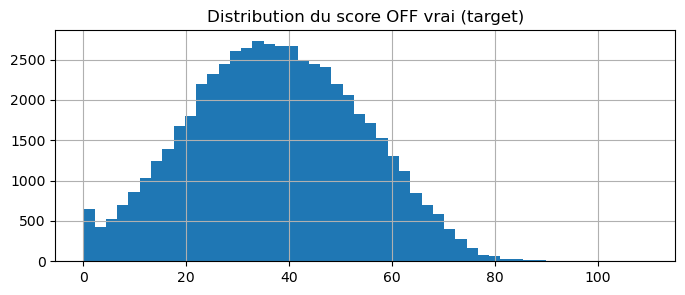

In [4]:
# Distribution de la cible
target = y_train["target"]
print(f"Target — min: {target.min():.1f} | max: {target.max():.1f} | mean: {target.mean():.1f} | std: {target.std():.1f}")
plt.figure(figsize=(8,3))
target.hist(bins=50)
plt.title("Distribution du score OFF vrai (target)")
plt.show()

## 2. Feature Engineering

### 2.1 — Proxy pharmacocinétique (le plus important !)

**Physique du problème** : La lévodopa a une demi-vie courte (~1-2h). L'effet du médicament décroît exponentiellement avec le temps depuis la prise. On peut modéliser :

```
drug_effect ≈ ledd × exp(-k × time_since_intake)
score_ON = score_OFF_vrai - drug_effect
→ proxy_OFF = score_ON + drug_effect_estimé
```

Le paramètre `k` est individuel, mais on peut l'approximer globalement. On va aussi laisser XGBoost apprendre la relation exacte via les features brutes.

In [8]:
def build_features(df, is_train=True):
    """
    Construit toutes les features à partir du dataframe brut.
    Garde patient_id pour l'agrégation par patient, puis le supprime.
    """
    d = df.copy()
    
    # ── 1. Features pharmacocinétiques ──────────────────────────────────
    # Taux de décroissance exponentielle de la lévodopa
    # k ≈ ln(2) / demi_vie. On essaie plusieurs valeurs de demi-vie (1h, 1.5h, 2h)
    for halflife in [1.0, 1.5, 2.0]:
        k = np.log(2) / halflife
        # Effet estimé du médicament au moment de l'évaluation ON
        d[f"drug_effect_on_hl{halflife}"] = d["ledd"] * np.exp(-k * d["time_since_intake_on"].fillna(999))
        # Proxy du score OFF basé sur la correction pharmacocinétique
        d[f"proxy_off_hl{halflife}"] = d["on"].fillna(0) + d[f"drug_effect_on_hl{halflife}"]
    
    # Résidu : écart entre score OFF brut et score ON (amplitude de l'effet)
    d["on_off_delta"] = d["off"].fillna(0) - d["on"].fillna(0)
    
    # Score ON corrigé par le temps (plus le temps est long, plus le score ON 
    # approche le score OFF vrai)
    d["on_time_normalized"] = d["on"].fillna(0) / (1 + np.exp(-d["time_since_intake_on"].fillna(0)))
    
    # Ratio posologie / âge (proxy de la charge médicamenteuse relative)
    d["ledd_per_year"] = d["ledd"] / (d["time_since_diagnosis"].fillna(1) + 1)
    
    # ── 2. Features temporelles par patient ─────────────────────────────
    # IMPORTANT : on garde patient_id pour le groupby, mais on ne le mettra
    # pas comme feature dans le modèle.
    
    # Trier par patient et temps depuis diagnostic (= chronologie)
    d = d.sort_values(["patient_id", "time_since_diagnosis"])
    
    # Score OFF de la visite précédente (lag)
    d["off_lag1"] = d.groupby("patient_id")["off"].shift(1)
    d["on_lag1"]  = d.groupby("patient_id")["on"].shift(1)
    
    # Moyenne des scores par patient (tendance de fond)
    d["off_patient_mean"] = d.groupby("patient_id")["off"].transform("mean")
    d["on_patient_mean"]  = d.groupby("patient_id")["on"].transform("mean")
    d["off_patient_std"]  = d.groupby("patient_id")["off"].transform("std")
    
    # Nombre de visites par patient (proxy de suivi long terme)
    d["n_visits"] = d.groupby("patient_id")["patient_id"].transform("count")
    
    # Rang de la visite (0 = première)
    d["visit_rank"] = d.groupby("patient_id").cumcount()
    
    # Pente estimée de progression (score OFF ~ temps depuis diagnostic)
    # On utilise la moyenne glissante sur les 3 dernières visites
    d["off_rolling_mean3"] = (
        d.groupby("patient_id")["off"]
         .transform(lambda x: x.shift(1).rolling(3, min_periods=1).mean())
    )
    
    # ── 3. Features démographiques / cliniques ───────────────────────────
    d["age_at_visit"]   = d["age"]  # déjà présent
    d["disease_duration"] = d["time_since_diagnosis"]
    
    # Interaction âge × durée maladie
    d["age_x_duration"] = d["age"] * d["time_since_diagnosis"].fillna(0)
    
    return d


# On fusionne X_train et y_train pour le feature engineering
train_full = X_train_raw.copy()
train_full["target"] = y_train["target"].values

train_fe = build_features(train_full, is_train=True)
test_fe  = build_features(X_test_raw,  is_train=False)

print("Features créées :", train_fe.shape[1])

Features créées : 34


### 2.2 — Encodage des variables catégorielles et gestion des NaN

In [9]:
# Colonnes à exclure du modèle
COLS_DROP = ["Index", "patient_id", "target"]
CAT_COLS  = ["cohort", "gene"]

def prepare_xy(df, fit_encoder=None, fit_scaler=None):
    """
    Prépare X (features) pour l'entraînement ou la prédiction.
    - Impute les NaN numériques par la MÉDIANE du train
    - Encode les catégorielles avec OHE
    - PAS de winsorisation : XGBoost/LightGBM gèrent les outliers
    - PAS de StandardScaler nécessaire pour les arbres, mais on le garde
      optionnel pour la Ridge de baseline
    """
    d = df.drop(columns=[c for c in COLS_DROP if c in df.columns], errors="ignore")
    
    # Séparer num / cat
    num_cols = d.select_dtypes(include=np.number).columns.tolist()
    
    # Imputation NaN
    if fit_encoder is None:  # = on est en train
        medians = d[num_cols].median()
        modes   = d[CAT_COLS].mode().iloc[0]
    else:
        medians = fit_encoder["medians"]
        modes   = fit_encoder["modes"]
    
    d[num_cols] = d[num_cols].fillna(medians)
    d[CAT_COLS] = d[CAT_COLS].fillna(modes)
    
    # OHE
    if fit_encoder is None:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        ohe.fit(d[CAT_COLS])
    else:
        ohe = fit_encoder["ohe"]
    
    ohe_arr = pd.DataFrame(
        ohe.transform(d[CAT_COLS]),
        columns=ohe.get_feature_names_out(CAT_COLS),
        index=d.index
    )
    d = d.drop(columns=CAT_COLS).join(ohe_arr)
    
    encoder_dict = {"medians": medians, "modes": modes, "ohe": ohe}
    return d, encoder_dict


X_all, enc = prepare_xy(train_fe)
y_all = train_fe["target"].values

X_test_final, _ = prepare_xy(test_fe, fit_encoder=enc)

# Aligner les colonnes train / test (OHE peut créer des colonnes différentes)
X_test_final = X_test_final.reindex(columns=X_all.columns, fill_value=0)

print(f"X_all: {X_all.shape} | X_test: {X_test_final.shape}")
print("NaN restants train:", X_all.isna().sum().sum())

X_all: (55603, 35) | X_test: (23672, 35)
NaN restants train: 0


## 3. Modélisation avec validation croisée

On utilise une **K-Fold cross-validation** pour estimer le RMSE de manière fiable, et on entraîne le modèle final sur l'ensemble du train.

**Attention** : pour des données longitudinales par patient, idéalement on ferait un `GroupKFold` (les visites d'un même patient restent dans le même fold). On le fera dans une V2.

In [10]:
XGB_PARAMS = dict(
    n_estimators          = 3000,
    learning_rate         = 0.02,
    max_depth             = 6,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 3,
    gamma                 = 0.05,
    reg_alpha             = 0.05,
    reg_lambda            = 1.0,
    objective             = "reg:squarederror",
    eval_metric           = "rmse",
    early_stopping_rounds = 100,
    random_state          = SEED,
    n_jobs                = -1,
    tree_method           = "hist",  # plus rapide
)

N_FOLDS = 5
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_preds = np.zeros(len(y_all))
test_preds_list = []
fold_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X_all)):
    X_tr, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
    y_tr, y_val = y_all[train_idx], y_all[val_idx]
    
    model = xgb.XGBRegressor(**XGB_PARAMS)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    val_pred = model.predict(X_val)
    oof_preds[val_idx] = val_pred
    
    rmse = root_mean_squared_error(y_val, val_pred)
    fold_scores.append(rmse)
    test_preds_list.append(model.predict(X_test_final))
    
    print(f"Fold {fold+1}/{N_FOLDS}  RMSE = {rmse:.4f}  (best iteration: {model.best_iteration})")

oof_rmse = root_mean_squared_error(y_all, oof_preds)
print(f"\n{'='*50}")
print(f"OOF RMSE global : {oof_rmse:.4f}")
print(f"Moyenne folds   : {np.mean(fold_scores):.4f} ± {np.std(fold_scores):.4f}")

Fold 1/5  RMSE = 3.2843  (best iteration: 2999)
Fold 2/5  RMSE = 3.2355  (best iteration: 2999)
Fold 3/5  RMSE = 3.2150  (best iteration: 2999)
Fold 4/5  RMSE = 3.1861  (best iteration: 2999)
Fold 5/5  RMSE = 3.1817  (best iteration: 2999)

OOF RMSE global : 3.2207
Moyenne folds   : 3.2205 ± 0.0375


## 4. LightGBM (si disponible) + Ensemble

In [ ]:
lgb_test_preds_list = []
lgb_oof = np.zeros(len(y_all))

if HAS_LGB:
    LGB_PARAMS = dict(
        n_estimators          = 3000,
        learning_rate         = 0.02,
        num_leaves            = 63,
        max_depth             = -1,
        subsample             = 0.8,
        colsample_bytree      = 0.8,
        min_child_samples     = 20,
        reg_alpha             = 0.05,
        reg_lambda            = 1.0,
        objective             = "regression",
        metric                = "rmse",
        random_state          = SEED,
        n_jobs                = -1,
        verbose               = -1,
    )
    
    lgb_fold_scores = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_all)):
        X_tr, X_val = X_all.iloc[train_idx], X_all.iloc[val_idx]
        y_tr, y_val = y_all[train_idx], y_all[val_idx]
        
        lgb_model = lgb.LGBMRegressor(**LGB_PARAMS)
        lgb_model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(False)]
        )
        
        val_pred = lgb_model.predict(X_val)
        lgb_oof[val_idx] = val_pred
        rmse = root_mean_squared_error(y_val, val_pred)
        lgb_fold_scores.append(rmse)
        lgb_test_preds_list.append(lgb_model.predict(X_test_final))
        print(f"[LGB] Fold {fold+1}/{N_FOLDS}  RMSE = {rmse:.4f}")
    
    lgb_oof_rmse = root_mean_squared_error(y_all, lgb_oof)
    print(f"\nLGB OOF RMSE : {lgb_oof_rmse:.4f}")
else:
    print("LightGBM non disponible, on saute cette étape.")

## 5. Prédictions finales et soumission

On moyenne les prédictions des folds (= bagging) et on combine XGB + LGB.

In [11]:
# Moyenne des prédictions de chaque fold sur le test set
xgb_test_preds = np.mean(test_preds_list, axis=0)

if HAS_LGB and len(lgb_test_preds_list) > 0:
    lgb_test_preds = np.mean(lgb_test_preds_list, axis=0)
    # Ensemble : poids 50/50 (à ajuster selon les OOF RMSE respectifs)
    # Si XGB RMSE < LGB RMSE, on peut mettre 60/40
    final_preds = 0.5 * xgb_test_preds + 0.5 * lgb_test_preds
    print("Ensemble XGB + LGB")
else:
    final_preds = xgb_test_preds
    print("XGB seul")

# Créer la soumission
# IMPORTANT : vérifier le format attendu par le site
# On utilise l'index du X_test original (après le drop de Index)
submission = pd.DataFrame({
    "id": X_test_raw["Index"].values,  # ou X_test_raw.index selon le format
    "target": final_preds
})

submission.to_csv("submission_v2.csv", index=False)
print(f"\nSoumission générée : {submission.shape}")
submission.head(10)

XGB seul

Soumission générée : (23672, 2)


,id,target
0,0,37.553757
1,1,36.984447
2,2,43.221207
3,3,49.883301
4,4,10.923582
5,5,13.741636
6,6,17.048008
7,7,21.506195
8,8,25.788427
9,9,22.926329


## 6. Analyse des features importantes

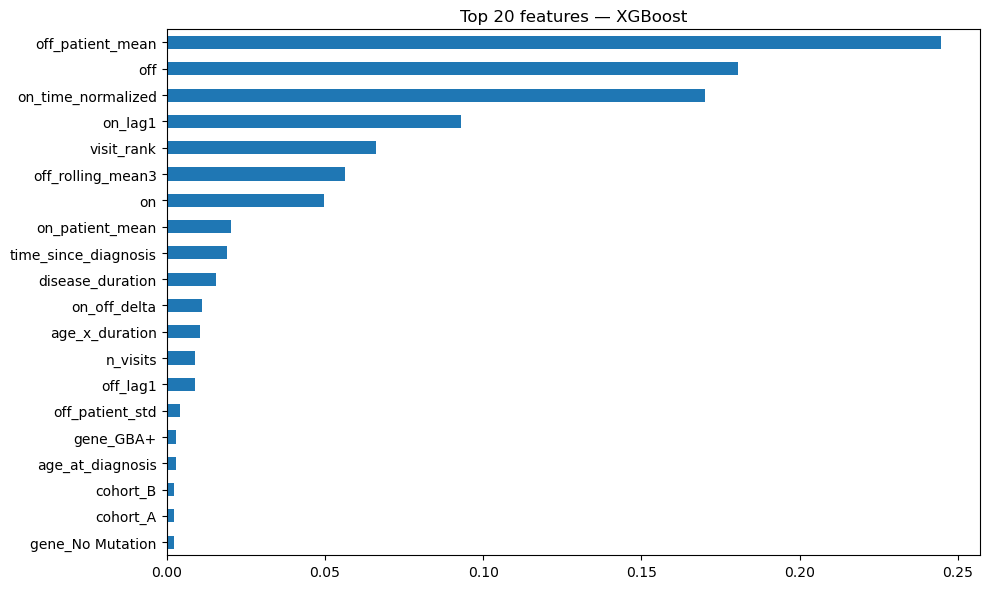

In [12]:
# On réentraîne un XGB sur tout le train pour l'importance des features
final_model = xgb.XGBRegressor(
    n_estimators  = 2000,  # fixe, pas d'early stopping sur tout le train
    learning_rate = 0.02,
    max_depth     = 6,
    subsample     = 0.8,
    colsample_bytree = 0.8,
    random_state  = SEED,
    n_jobs        = -1,
    tree_method   = "hist",
)
final_model.fit(X_all, y_all, verbose=False)

fi = pd.Series(final_model.feature_importances_, index=X_all.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
fi.head(20).plot(kind="barh")
plt.gca().invert_yaxis()
plt.title("Top 20 features — XGBoost")
plt.tight_layout()
plt.show()

## 7. Pistes d'amélioration supplémentaires

Si le score reste > 15 :

1. **GroupKFold par patient** : s'assurer que les visites d'un même patient ne fuient pas entre train et validation
2. **Modèle à effets mixtes** : un LME (Linear Mixed Effects) peut capturer la trajectoire individuelle de chaque patient
3. **Optimisation bayésienne des hyperparamètres** : `optuna` sur les params XGB/LGB
4. **Calibration PK individuelle** : si on a assez de visites par patient, on peut estimer `k` individuellement
5. **CatBoost** : souvent très fort sur des données tabulaires avec catégorielles